In [1]:
import pandas as pd
import os
from nilearn import plotting
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from pathlib import Path
from nilearn.image import resample_to_img
from nilearn import plotting, image, datasets
from scipy.ndimage import label
import numpy as np
import matplotlib.pyplot as plt
from atlasreader import create_output

The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data



In [2]:
virtueORvice = 'virtues' # vices, virtues
whichStory = "prettymouth"
whichStory1 = "prettymouthaffair"  
whichStory2 = "prettymouthparanoia"  

whichFoundation = '5' # 1 to 7

# 1 to 7 maps onto the following foundations MAC:
# 1 = deference
# 2 = fairness
# 3 = family
# 4 = group
# 5 = heroism
# 6 = property
# 7 = reciprocity

# output directory
base_dir1 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
)

output_dir = Path(f"{base_dir1}{virtueORvice}/vsBaseline/compareGroups/{whichFoundation}/{whichStory}/")

# make the output directory if it does not exist: 
output_dir.mkdir(parents=True, exist_ok=True)

# results directory

if virtueORvice == 'virtues':
    virtueORviceDataFolder = '7_MAC'

if virtueORvice == 'vices':
    virtueORviceDataFolder = '7_MAC_V'

base_dir2 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)

results_dir_affair = Path(f"{base_dir2}{whichStory1}/{virtueORviceDataFolder}/VsBaseline/")
results_dir_paranoia = Path(f"{base_dir2}{whichStory2}/{virtueORviceDataFolder}/VsBaseline/")

In [3]:
files_affair = sorted(
    results_dir_affair.glob(f"*foundation{whichFoundation}_vsBaseline.nii.gz")
)

print(f"Found {len(files_affair)} images.")


Found 20 images.


In [4]:
files_paranoia = sorted(
    results_dir_paranoia.glob(f"*foundation{whichFoundation}_vsBaseline.nii.gz")
)

print(f"Found {len(files_paranoia)} images.")

Found 20 images.


In [5]:
# Convert PosixPaths → strings
files_affair = [str(f) for f in files_affair]
files_paranoia = [str(f) for f in files_paranoia]

# Combine all files into one list
all_imgs = files_affair + files_paranoia

# resample
ref = all_imgs[0]
imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]


# Create design matrix
design_matrix = pd.DataFrame({
    'intercept': 1,
    'group': [1]*len(files_affair) + [0]*len(files_paranoia)
})


/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_9189/99971178.py:10: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


In [6]:
design_matrix

,intercept,group
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


In [7]:

# Initialize and fit the model
second_level_model = SecondLevelModel() #smoothing_fwhm=6.0
second_level_model = second_level_model.fit(all_imgs, design_matrix=design_matrix)

# Compute the group contrast (Affair > Paranoia)
z_map = second_level_model.compute_contrast('group', output_type='z_score')
z_map.to_filename(str(output_dir)+'/affair_over_paranoia_zmap.nii.gz')

# And for the reverse contrast:
z_map_rev = second_level_model.compute_contrast('-group', output_type='z_score')
z_map_rev.to_filename(str(output_dir)+'/paranoia_over_affair_zmap.nii.gz')

In [8]:
# do fdr correction
thresholded_map, threshold_1 = threshold_stats_img(
    z_map, alpha=0.05, height_control='fdr'
)
thresholded_map.to_filename(str(output_dir)+'/affair_over_paranoia_FDR05.nii.gz')

print(threshold_1)

create_output(str(output_dir)+'/affair_over_paranoia_FDR05.nii.gz',
              cluster_extent=10,direction="pos",outdir=str(output_dir))


# do fdr correction
thresholded_map, threshold_2 = threshold_stats_img(
    z_map_rev, alpha=0.05, height_control='fdr'
)
thresholded_map.to_filename(str(output_dir)+'/paranoia_over_affair_FDR05.nii.gz')

print(threshold_2)

create_output(str(output_dir)+'/paranoia_over_affair_FDR05.nii.gz',
              cluster_extent=10,direction="pos",outdir=str(output_dir))

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.847964397169893. But, you have given threshold=inf.
  stat_img = threshold_img(


inf


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:313: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.847964397169893. But, you have given threshold=inf.
  stat_img = threshold_img(


inf


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:313: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)


In [9]:

# do cluster correction
thresholded_map, threshold_1 = threshold_stats_img(
    z_map, alpha=0.001, height_control='fpr',cluster_threshold=10
)
thresholded_map.to_filename(str(output_dir)+'/affair_over_paranoia_fpr_clusterThreshold10.nii.gz')

print(threshold_1)

create_output(str(output_dir)+'/affair_over_paranoia_fpr_clusterThreshold10.nii.gz',
              cluster_extent=10,direction="pos",outdir=str(output_dir))

# do cluster correction
thresholded_map, threshold_2 = threshold_stats_img(
    z_map_rev, alpha=0.001, height_control='fpr',cluster_threshold=10
)
thresholded_map.to_filename(str(output_dir)+'/paranoia_over_affair_fpr_clusterThreshold10.nii.gz')

print(threshold_2)

create_output(str(output_dir)+'/paranoia_over_affair_fpr_clusterThreshold10.nii.gz',
              cluster_extent=10,direction="pos",outdir=str(output_dir))


3.2905267314918945


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:313: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)


3.2905267314918945


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:313: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)


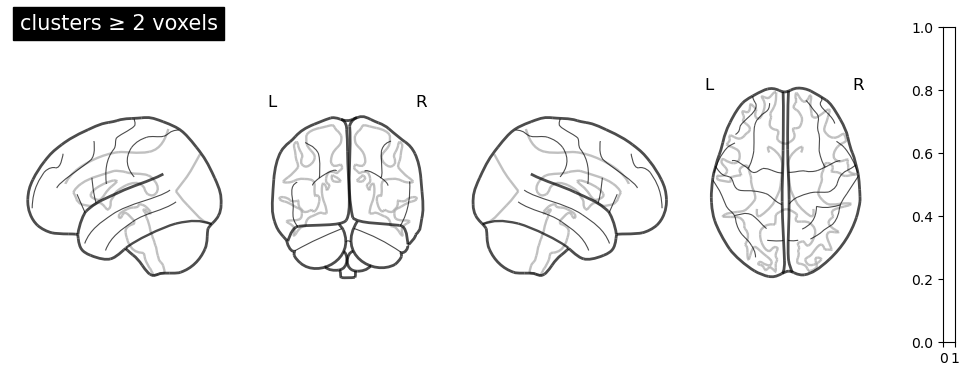

In [10]:
stat_img = image.load_img(str(output_dir)+'/affair_over_paranoia_fpr_clusterThreshold10.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/affair_over_paranoia_fpr_clusterThreshold10.png', dpi=300)  

plt.show()

display.close()

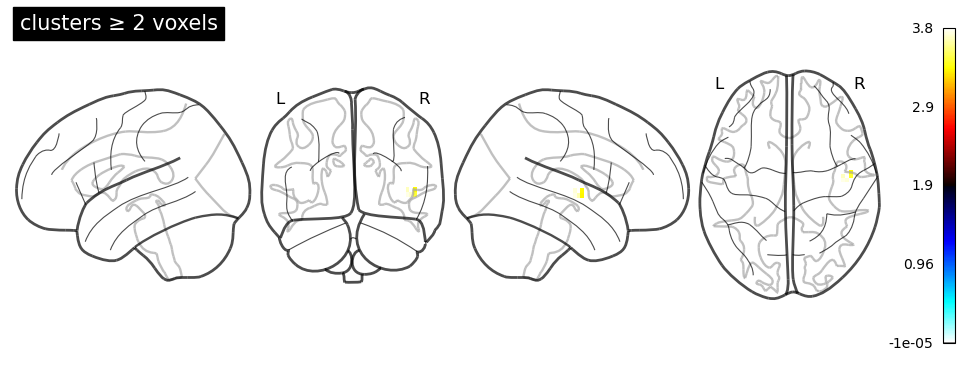

In [11]:
stat_img = image.load_img(str(output_dir)+'/paranoia_over_affair_fpr_clusterThreshold10.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/paranoia_over_affair_fpr_clusterThreshold10.png', dpi=300)  

plt.show()

display.close()